In [1]:
import scipy.io, h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from pathlib import Path
import os
import glob
import re
import math

In [ ]:
import json
from datetime import datetime
from pathlib import Path

def save_metrics_to_json(metrics_dict, model_name, dataset_name, output_dir="../../outputs/reports/"):
    """
    Save metrics dictionary to JSON file with timestamp
    Converts NumPy types to native Python types for JSON serialization
    """
    def convert_to_serializable(obj):
        """Convert NumPy types to native Python types"""
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, dict):
            return {key: convert_to_serializable(value) for key, value in obj.items()}
        elif isinstance(obj, list):
            return [convert_to_serializable(item) for item in obj]
        return obj
    
    # Convert metrics to serializable format, excluding non-serializable keys
    clean_metrics = {}
    for key, value in metrics_dict.items():
        # Skip predictions and targets arrays if you don't want them
        if key in ['predictions', 'targets']:
            continue
        clean_metrics[key] = convert_to_serializable(value)
    
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"{model_name}_{dataset_name}_metrics.json"
    filepath = output_path / filename
    
    with open(filepath, 'w') as f:
        json.dump(clean_metrics, f, indent=4)
    
    print(f"✅ Saved {model_name} metrics to: {filepath}")
    return str(filepath)

In [3]:
def load_mat_any(path):
    try:
        m = scipy.io.loadmat(path, squeeze_me=True, struct_as_record=False)
        return ('scipy', m)
    except NotImplementedError:
        f = h5py.File(path, 'r')
        return ('h5py', f)


In [4]:
DATA_PATH_RAW = Path("../data/raw/") 
LAYUP1_PATH = "Layup1"
COPUN_ID = "L1_S11_F"
print(f"Data root: {DATA_PATH_RAW.resolve()}")

PZT_DIR   = DATA_PATH_RAW / LAYUP1_PATH / COPUN_ID / "PZT-data"
STRAIN_DIR= DATA_PATH_RAW / LAYUP1_PATH / COPUN_ID / "StrainData"


Data root: D:\pichla_laptop\IITG material\4th year\7th-sem\BTP-Explainable AI\CFRP_Composit_Materials_Analysis\data\raw


In [5]:
#pzt_files = glob.glob("L1_S11_F/PZT-data/*.mat")
pzt_files = glob.glob(str(PZT_DIR.resolve()) + "/*.mat")
strain_files = glob.glob(str(STRAIN_DIR.resolve()) + "/*.mat")

print(f"PZT files: {len(pzt_files)}")
print(f"Strain files: {len(strain_files)}")

# Look at file naming patterns
for i, file in enumerate(sorted(pzt_files)[:10]):
    print(f"{i+1}: {os.path.basename(file)}")

PZT files: 145
Strain files: 80
1: L1S11_0_0.mat
2: L1S11_0_1_1.mat
3: L1S11_0_1_10.mat
4: L1S11_0_1_11.mat
5: L1S11_0_1_12.mat
6: L1S11_0_1_13.mat
7: L1S11_0_1_14.mat
8: L1S11_0_1_15.mat
9: L1S11_0_1_16.mat
10: L1S11_0_1_17.mat


In [6]:
# Load and examine a baseline file
mode, mat = load_mat_any(str(PZT_DIR.resolve()) + "/L1S11_0_0.mat")
print("Baseline file structure:")
print("Keys:", [k for k in mat.keys() if not k.startswith('__')])

# Load a test file with cycles
mode, mat = load_mat_any(str(PZT_DIR.resolve()) + "/L1S11_100000_1_2.mat")
print("\nTest file structure:")
print("Keys:", [k for k in mat.keys() if not k.startswith('__')])

Baseline file structure:
Keys: ['coupon']

Test file structure:
Keys: ['coupon']


In [7]:
def parse_pzt_filename(filename):
    """Extract cycle count, actuator, sensor from filename"""
    basename = os.path.basename(filename)
    match = re.match(r'L1S11_(\d+)_(\d+)_(\d+)\.mat', basename)
    if match:
        return {
            'filename': basename,
            'cycles': int(match.group(1)),
            'actuator': int(match.group(2)),
            'sensor': int(match.group(3))
        }
    return None

# Create inventory
pzt_inventory = []
for file in pzt_files:
    info = parse_pzt_filename(file)
    if info:
        pzt_inventory.append(info)

df_inventory = pd.DataFrame(pzt_inventory)
print("Data inventory:")
print(df_inventory.head())
print(f"\nCycle counts available: {sorted(df_inventory['cycles'].unique())}")
print(f"Actuator-Sensor pairs: {df_inventory[['actuator', 'sensor']].drop_duplicates().values}")

Data inventory:
           filename  cycles  actuator  sensor
0   L1S11_0_1_1.mat       0         1       1
1  L1S11_0_1_10.mat       0         1      10
2  L1S11_0_1_11.mat       0         1      11
3  L1S11_0_1_12.mat       0         1      12
4  L1S11_0_1_13.mat       0         1      13

Cycle counts available: [np.int64(0), np.int64(1), np.int64(10), np.int64(100), np.int64(1000), np.int64(10000), np.int64(20000), np.int64(30000), np.int64(40000), np.int64(50000), np.int64(60000), np.int64(70000), np.int64(80000), np.int64(90000), np.int64(100000), np.int64(125000), np.int64(150000), np.int64(175000), np.int64(177000), np.int64(177309), np.int64(227000)]
Actuator-Sensor pairs: [[ 1  1]
 [ 1 10]
 [ 1 11]
 [ 1 12]
 [ 1 13]
 [ 1 14]
 [ 1 15]
 [ 1 16]
 [ 1 17]
 [ 1 18]
 [ 1 19]
 [ 1  2]
 [ 1 20]
 [ 1 21]
 [ 1 22]
 [ 1  3]
 [ 1  4]
 [ 1  5]
 [ 1  6]
 [ 1  7]
 [ 1  8]
 [ 1  9]
 [ 2  1]
 [ 2  2]
 [ 2  3]
 [ 2  4]
 [ 3  1]
 [ 3  2]
 [ 3  3]]


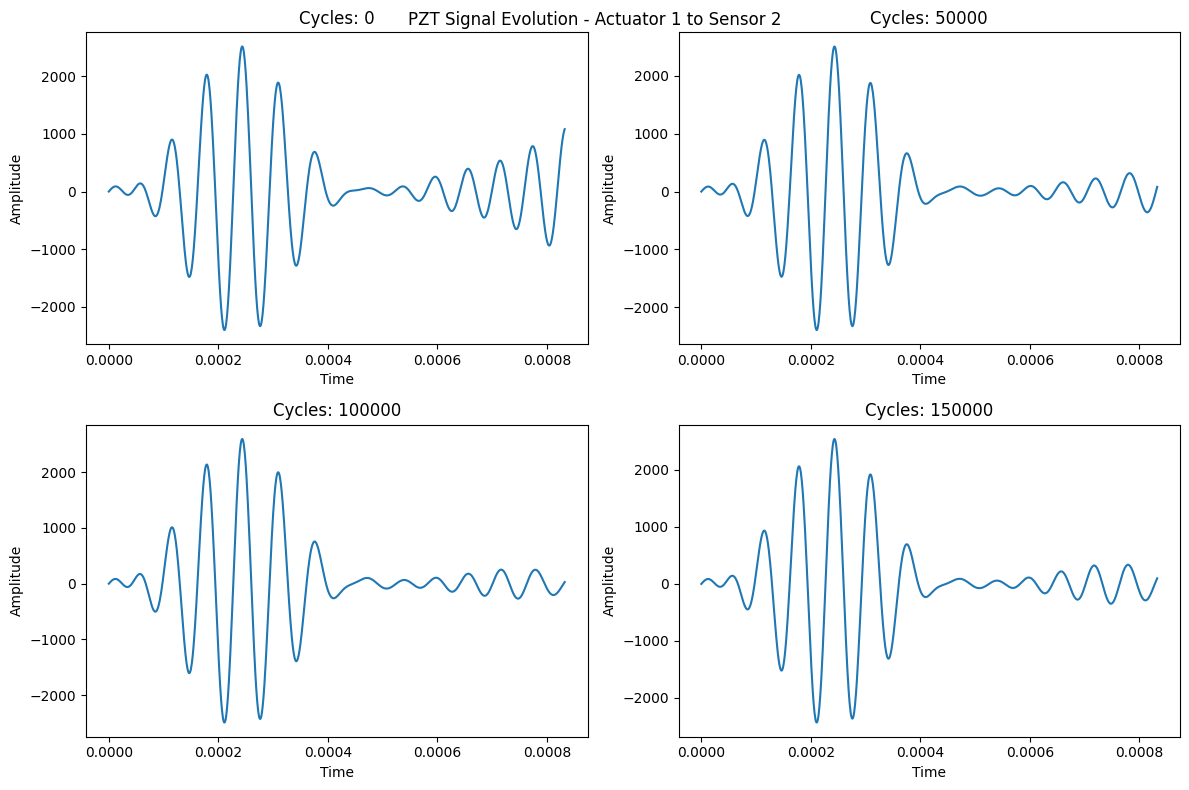

In [8]:
import matplotlib.pyplot as plt

def plot_pzt_progression(actuator=1, sensor=2, cycles_to_plot=[0, 50000, 100000, 150000]):
    """Plot PZT signals at different cycle counts"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    
    for i, cycles in enumerate(cycles_to_plot):
        filename = f"{str(PZT_DIR.resolve())}/L1S11_{cycles}_{actuator}_{sensor}.mat"
        if os.path.exists(filename):
            mode, mat = load_mat_any(filename)
            
            # Extract signal data (adjust based on actual structure)
            if 'coupon' in mat:
                signal = mat['coupon'].path_data[0].signal_sensor
                fs = mat['coupon'].path_data[0].sampling_rate
                t = np.arange(len(signal)) / fs
            else:
                # Fallback if structure is different
                signal = list(mat.values())[0]
                t = np.arange(len(signal))
            
            axes[i].plot(t[:1000], signal[:1000])  # Plot first 1000 points
            axes[i].set_title(f'Cycles: {cycles}')
            axes[i].set_xlabel('Time')
            axes[i].set_ylabel('Amplitude')
    
    plt.tight_layout()
    plt.suptitle(f'PZT Signal Evolution - Actuator {actuator} to Sensor {sensor}')
    plt.show()

# Plot progression
plot_pzt_progression()

In [9]:
# Create damage labels based on cycle count
def assign_damage_level(cycles):
    """Assign damage level based on fatigue cycles"""
    if cycles == 0:
        return 'Healthy'
    elif cycles < 50000:
        return 'Early_Damage'
    elif cycles < 100000:
        return 'Moderate_Damage'
    elif cycles < 150000:
        return 'Significant_Damage'
    else:
        return 'Severe_Damage'

# Add labels to inventory
df_inventory['damage_level'] = df_inventory['cycles'].apply(assign_damage_level)
print("Damage level distribution:")
print(df_inventory['damage_level'].value_counts())

Damage level distribution:
damage_level
Early_Damage          48
Moderate_Damage       31
Healthy               28
Severe_Damage         25
Significant_Damage    12
Name: count, dtype: int64


In [10]:
def extract_features(signal):
    """Extract basic features from PZT signal"""
    features = {
        'max_amplitude': np.max(np.abs(signal)),
        'rms': np.sqrt(np.mean(signal**2)),
        'energy': np.sum(signal**2),
        'peak_frequency': None,  # Add FFT-based features
        'spectral_centroid': None
    }
    
    # Add frequency domain features
    fft = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal))
    power_spectrum = np.abs(fft)**2
    
    features['peak_frequency'] = freqs[np.argmax(power_spectrum[:len(freqs)//2])]
    features['spectral_centroid'] = np.sum(freqs[:len(freqs)//2] * power_spectrum[:len(freqs)//2]) / np.sum(power_spectrum[:len(freqs)//2])
    
    return features

In [11]:
def load_strain_channels(fp):
    mode, mat = load_mat_any(fp)
    channels = []
    if mode == 'scipy':
        keys = [k for k in mat.keys() if not k.startswith('__')]
        for k in keys:
            if k.lower().startswith('strain'):
                arr = np.array(mat[k]).squeeze()
                channels.append((k, arr))
    else:  # h5py
        keys = list(mat.keys())
        for k in keys:
            if 'strain' in k.lower():
                arr = np.array(mat[k]).squeeze()
                channels.append((k, arr))
        mat.close()
    return channels



Inspecting: L1_S11_F00_DAT.mat
  strain4: shape=(600,), dtype=float64
  strain2: shape=(600,), dtype=float64
  strain1: shape=(600,), dtype=float64
  strain3: shape=(600,), dtype=float64


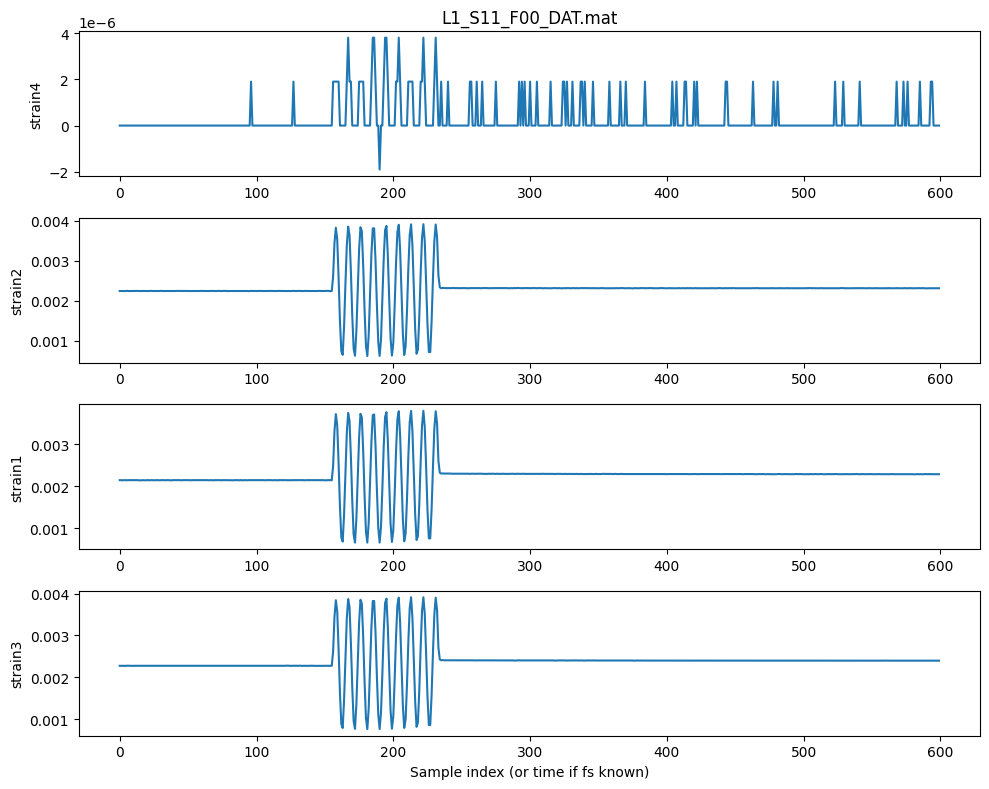

,filename,n_channels,len_first
0,L1_S11_F00_DAT.mat,4,600
1,L1_S11_F01_STRAIN_A_DAT.mat,4,9850
2,L1_S11_F01_STRAIN_M_DAT.mat,4,8500
3,L1_S11_F01_STRAIN_S_DAT.mat,4,8850
4,L1_S11_F02_DAT.mat,4,2350


,filename,n_channels,len_first
0,L1_S11_F00_DAT.mat,4,600
1,L1_S11_F01_STRAIN_A_DAT.mat,4,9850
2,L1_S11_F01_STRAIN_M_DAT.mat,4,8500
3,L1_S11_F01_STRAIN_S_DAT.mat,4,8850
4,L1_S11_F02_DAT.mat,4,2350
...,...,...,...
75,L1_S11_S08_STRAIN_S_DAT.mat,4,15950
76,L1_S11_S10_DAT.mat,4,130900
77,L1_S11_S10_STRAIN_A_DAT.mat,4,17300
78,L1_S11_S10_STRAIN_M_DAT.mat,4,15500


Example features (first file, first channel): {'mean': 2.8571497143032383e-07, 'std': 7.559308946415993e-07, 'rms': 8.081241008490462e-07, 'ptp': 5.714297142925715e-06}


In [12]:

# Inspect first file and print shapes
if strain_files:
    fp0 = strain_files[0]
    print("\nInspecting:", os.path.basename(fp0))
    channels = load_strain_channels(fp0)
    for name, arr in channels:
        print(f"  {name}: shape={arr.shape}, dtype={arr.dtype}")

    # Plot all strain channels from first file
    if channels:
        plt.figure(figsize=(10, 2*len(channels)))
        for i, (name, arr) in enumerate(channels):
            t = np.arange(len(arr))  # samples; replace with np.arange(len(arr))/fs if you know fs
            ax = plt.subplot(len(channels), 1, i+1)
            ax.plot(t, arr)
            ax.set_ylabel(name)
            if i == 0:
                ax.set_title(os.path.basename(fp0))
        ax.set_xlabel("Sample index (or time if fs known)")
        plt.tight_layout()
        plt.show()

# Build a small inventory (one row per file)
inv = []
for fp in strain_files:
    chs = load_strain_channels(fp)
    inv.append({
        'filename': os.path.basename(fp),
        'n_channels': len(chs),
        'len_first': chs[0][1].shape[0] if chs else None
    })
df_strain = pd.DataFrame(inv)
display(df_strain.head())
display(df_strain)

# Example feature extraction on first file, first channel
if strain_files and df_strain.loc[0,'n_channels']>0:
    name, sig = load_strain_channels(strain_files[0])[0]
    feats = {
        'mean': float(np.mean(sig)),
        'std': float(np.std(sig)),
        'rms': float(np.sqrt(np.mean(sig**2))),
        'ptp': float(np.ptp(sig))
    }
    print("Example features (first file, first channel):", feats)

In [13]:
# list unique coupon.condition values across pzt_files
conds = []
for fp in pzt_files:
    mode, mat = load_mat_any(fp)
    try:
        if mode == 'scipy':
            coupon = mat.get('coupon', None)
            cond = getattr(coupon, 'condition', None) if coupon is not None else None
        else:  # h5py
            grp = mat['coupon']
            cond = grp.attrs.get('condition', None)
            # decode bytes if necessary
            if isinstance(cond, (bytes, np.ndarray)):
                try:
                    cond = cond.decode() if isinstance(cond, bytes) else np.array(cond).tolist()
                except Exception:
                    pass
    finally:
        if mode == 'h5py' and hasattr(mat, 'close'):
            mat.close()
    conds.append(cond)

print(sorted(set(conds)))

['Baseline', 'Clamped', 'Loaded', 'Traction Free', 'Traction free', 'clamped', 'loaded', 'traction free']


In [14]:
def explore_mat_full(path, max_depth=6, max_items=50):
    """Print a detailed recursive view of a .mat file (scipy or h5py)."""
    mode, mat = load_mat_any(path)
    print(f"\n=== EXPLORING: {path}  (mode={mode}) ===\n")
    
    def pp(obj, name, depth):
        indent = "  " * depth
        if depth > max_depth:
            print(f"{indent}{name}: <max depth reached>")
            return
        try:
            # h5py objects
            import h5py
            if isinstance(obj, h5py.File) or isinstance(obj, h5py.Group) or isinstance(obj, h5py.Dataset):
                if isinstance(obj, h5py.Dataset):
                    print(f"{indent}{name}: Dataset, shape={obj.shape}, dtype={obj.dtype}")
                    # show small preview
                    try:
                        sample = obj[tuple([0]* (len(obj.shape))) if obj.shape else 0]
                    except Exception:
                        sample = None
                    if sample is not None:
                        print(f"{indent}  preview: {np.array(sample).shape} dtype={type(sample)}")
                else:
                    print(f"{indent}{name}: Group, keys={list(obj.keys())}, attrs={dict(obj.attrs)}")
                    count = 0
                    for k in obj.keys():
                        if count >= max_items: 
                            print(f"{indent}  ... ({len(list(obj.keys()))-max_items} more keys)")
                            break
                        pp(obj[k], f"{name}/{k}", depth+1)
                        count += 1
                return
        except Exception:
            pass
        
        # scipy-loadmat: dict-like top-level
        if isinstance(obj, dict):
            keys = [k for k in obj.keys() if not k.startswith('__')]
            print(f"{indent}{name}: dict, keys={keys}")
            for k in keys[:max_items]:
                pp(obj[k], f"{name}.{k}", depth+1)
            if len(keys) > max_items:
                print(f"{indent}  ... ({len(keys)-max_items} more keys)")
            return
        
        # numpy arrays (including MATLAB structs as object arrays)
        if isinstance(obj, np.ndarray):
            print(f"{indent}{name}: ndarray, shape={obj.shape}, dtype={obj.dtype}")
            # if structured array (matlab struct), try to inspect first element(s)
            if obj.dtype == np.object_ or obj.dtype.names is not None:
                # object array: show first few entries
                n_show = min(3, obj.shape[0] if obj.shape else 1)
                for i in range(n_show):
                    try:
                        pp(obj[i], f"{name}[{i}]", depth+1)
                    except Exception:
                        print(f"{indent}  {name}[{i}]: <cannot access>")
            return
        
        # numpy scalar or python primitives
        if isinstance(obj, (np.generic, float, int, str, bytes)):
            print(f"{indent}{name}: {type(obj).__name__} = {repr(obj)[:200]}")
            return
        
        # generic object (e.g., scipy.io.matlab.mio5_params.mat_struct)
        # try dir() to list attributes
        try:
            attrs = [a for a in dir(obj) if not a.startswith('_')]
            if attrs:
                print(f"{indent}{name}: object type={type(obj)}, attrs={attrs}")
                for a in attrs[:max_items]:
                    try:
                        val = getattr(obj, a)
                        # avoid recursing into large arrays as-is
                        if isinstance(val, (np.ndarray, list, dict)) or hasattr(val, '__dict__'):
                            pp(val, f"{name}.{a}", depth+1)
                        else:
                            print(f"{indent}  {a}: {type(val).__name__}")
                    except Exception:
                        print(f"{indent}  {a}: <cannot access>")
                return
        except Exception:
            pass
        
        # fallback
        print(f"{indent}{name}: {type(obj)} (no further detail)")

    # start
    try:
        pp(mat, "root", 0)
    finally:
        # close h5py file if returned
        if mode == 'h5py' and hasattr(mat, 'close'):
            try:
                mat.close()
            except:
                pass

# Example usage: inspect baseline and a later file
explore_mat_full(str(PZT_DIR.resolve())+"/L1S11_0_0.mat")
explore_mat_full(str(PZT_DIR.resolve())+"/L1S11_100000_1_2.mat")



=== EXPLORING: D:\pichla_laptop\IITG material\4th year\7th-sem\BTP-Explainable AI\CFRP_Composit_Materials_Analysis\data\raw\Layup1\L1_S11_F\PZT-data/L1S11_0_0.mat  (mode=scipy) ===

root: dict, keys=['coupon']
  root.coupon: object type=<class 'scipy.io.matlab._mio5_params.mat_struct'>, attrs=['XRay_data', 'comment', 'condition', 'cycles', 'load', 'path_data', 'straingage_data']
    root.coupon.XRay_data: object type=<class 'scipy.io.matlab._mio5_params.mat_struct'>, attrs=['file_location']
      file_location: str
    comment: str
    condition: str
    cycles: int
    load: int
    root.coupon.path_data: ndarray, shape=(252,), dtype=object
      root.coupon.path_data[0]: object type=<class 'scipy.io.matlab._mio5_params.mat_struct'>, attrs=['actuator', 'amplitude', 'frequency', 'gain', 'sampling_rate', 'sensor', 'signal_actuator', 'signal_sensor']
        actuator: int
        amplitude: int
        frequency: int
        gain: int
        sampling_rate: int
        sensor: int
     

In [15]:

# def print_pzt_data(fp, max_print=200):
#     mode, mat = load_mat_any(fp)
#     print(f"\n=== PZT FILE: {fp}  (mode={mode}) ===")
#     if mode == 'scipy':
#         keys = [k for k in mat.keys() if not k.startswith('__')]
#         print("Top-level keys:", keys)
#         if 'coupon' not in mat:
#             print("No 'coupon' key found; aborting detailed print.")
#             return
#         coupon = mat['coupon']
#         # coupon-level attributes
#         for a in ('cycles', 'load', 'condition', 'comment'):
#             val = getattr(coupon, a, None)
#             if val is not None:
#                 print(f"coupon.{a} = {val}")
#         # nested XRay / straingage info if present
#         xr = getattr(coupon, 'XRay_data', None)
#         if xr is not None:
#             loc = getattr(xr, 'file_location', None)
#             print(f"coupon.XRay_data.file_location = {loc}")
#         sg = getattr(coupon, 'straingage_data', None)
#         if sg is not None:
#             loc = getattr(sg, 'file_location', None)
#             stiff = getattr(sg, 'stiffness_degradation', None)
#             print(f"coupon.straingage_data.file_location = {loc}")
#             print(f"coupon.straingage_data.stiffness_degradation = {stiff}")
#         pd = getattr(coupon, 'path_data', None)
#         if pd is None:
#             print("No path_data found inside coupon.")
#             return
#         paths = pd if (hasattr(pd, '__len__') and not isinstance(pd, (str, bytes))) else [pd]
#         for i, p in enumerate(paths):
#             print(f"\n-- Path {i} --")
#             # print common path attributes
#             for attr in ('actuator', 'sensor', 'amplitude', 'frequency', 'gain', 'sampling_rate'):
#                 v = getattr(p, attr, None)
#                 print(f"  {attr} = {v}")
#             # signals
#             sig = None
#             sig_name = None
#             for name in ('signal_sensor', 'signal_rec', 'signal', 'signal_received'):
#                 if hasattr(p, name):
#                     sig = np.array(getattr(p, name)).squeeze()
#                     sig_name = name
#                     break
#             if hasattr(p, 'signal_actuator'):
#                 sa = np.array(getattr(p, 'signal_actuator')).squeeze()
#                 print(f"  signal_actuator: shape={sa.shape} dtype={sa.dtype}")
#             if sig is None:
#                 print("  No signal array found for this path.")
#                 continue
#             fs = getattr(p, 'sampling_rate', getattr(p, 'fs', None))
#             print(f"  signal attribute: {sig_name}  shape={sig.shape}  dtype={sig.dtype}")
#             print("  stats: min, max, mean, std =", float(np.min(sig)), float(np.max(sig)), float(np.mean(sig)), float(np.std(sig)))
#             L = sig.size
#             nprint = L if L <= max_print else max_print
#             print(f"  printing first {nprint} / {L} samples:")
#             print(sig.flatten()[:nprint])
#             if fs:
#                 try:
#                     t = np.arange(L) / float(fs)
#                     xlabel = "Time (s)"
#                 except Exception:
#                     t = np.arange(L)
#                     xlabel = "Sample index"
#             else:
#                 t = np.arange(L)
#                 xlabel = "Sample index"
#             plt.figure(figsize=(10,2))
#             plt.plot(t, sig)
#             plt.title(f"{os.path.basename(fp)}  Path {i}: A{getattr(p,'actuator',None)}->S{getattr(p,'sensor',None)}")
#             plt.xlabel(xlabel)
#             plt.ylabel("Amplitude")
#             plt.tight_layout()
#             plt.show()
#     else:
#         f = mat
#         print("Top-level groups:", list(f.keys()))
#         if 'coupon' not in f:
#             print("No coupon group; printing groups and datasets.")
#             for k in f.keys():
#                 try:
#                     obj = f[k]
#                     print(f"Group '{k}': members = {list(obj.keys())}")
#                 except Exception:
#                     pass
#             f.close()
#             return
#         grp = f['coupon']
#         # coupon-level attrs (h5py)
#         try:
#             for a in ('cycles', 'load', 'condition', 'comment'):
#                 if a in grp.attrs:
#                     print(f"coupon.attr.{a} = {grp.attrs[a]}")
#         except Exception:
#             pass
#         if 'XRay_data' in grp:
#             xr = grp['XRay_data']
#             if 'file_location' in xr:
#                 print("coupon.XRay_data.file_location:", np.array(xr['file_location']).tolist())
#         if 'straingage_data' in grp:
#             sg = grp['straingage_data']
#             if 'file_location' in sg:
#                 print("coupon.straingage_data.file_location:", np.array(sg['file_location']).tolist())
#             if 'stiffness_degradation' in sg:
#                 print("coupon.straingage_data.stiffness_degradation:", np.array(sg['stiffness_degradation']).tolist())
#         if 'path_data' in grp:
#             pd = grp['path_data']
#             for name in pd.keys():
#                 sub = pd[name]
#                 print(f"\n-- path_data/{name} -- keys: {list(sub.keys())} attrs: {dict(sub.attrs)}")
#                 # print common attrs from dataset/group attrs
#                 for attr in ('actuator','sensor','amplitude','frequency','gain','sampling_rate'):
#                     if attr in sub.attrs:
#                         print(f"  {attr} = {sub.attrs[attr]}")
#                 if 'signal_sensor' in sub:
#                     sig = np.array(sub['signal_sensor']).squeeze()
#                     print("  signal_sensor shape:", sig.shape, "dtype:", sig.dtype)
#                     print("  first samples:", sig.flatten()[:min(len(sig), max_print)])
#                     L = sig.size
#                     fs = sub.attrs.get('sampling_rate', None)
#                     if fs:
#                         t = np.arange(L)/float(fs); xlabel = "Time (s)"
#                     else:
#                         t = np.arange(L); xlabel = "Sample index"
#                     plt.figure(figsize=(10,2)); plt.plot(t, sig); plt.title(name); plt.xlabel(xlabel); plt.tight_layout(); plt.show()
#         else:
#             print("coupon/path_data not found in h5py file.")
#         f.close()

# def print_strain_data(fp, max_print=200):
#     mode, mat = load_mat_any(fp)
#     print(f"\n=== STRAIN FILE: {fp}  (mode={mode}) ===")
#     if mode == 'scipy':
#         keys = [k for k in mat.keys() if not k.startswith('__')]
#         print("Top-level keys:", keys)
#         for k in keys:
#             if k.lower().startswith('strain'):
#                 arr = np.array(mat[k]).squeeze()
#                 print(f"\n{k}: shape={arr.shape} dtype={arr.dtype}")
#                 print("stats: min, max, mean, std =", float(np.min(arr)), float(np.max(arr)), float(np.mean(arr)), float(np.std(arr)))
#                 nprint = arr.size if arr.size <= max_print else max_print
#                 print(f"first {nprint}/{arr.size} samples:\n", arr.flatten()[:nprint])
#                 t = np.arange(arr.size)
#                 plt.figure(figsize=(10,2)); plt.plot(t, arr); plt.title(f"{os.path.basename(fp)}  {k}"); plt.xlabel("Sample index"); plt.tight_layout(); plt.show()
#     else:
#         f = mat
#         print("Top-level groups:", list(f.keys()))
#         for name in f.keys():
#             if 'strain' in name.lower():
#                 ds = f[name]
#                 arr = np.array(ds).squeeze()
#                 print(f"\n{name}: shape={arr.shape} dtype={arr.dtype}")
#                 print("first samples:", arr.flatten()[:min(len(arr), max_print)])
#                 plt.figure(figsize=(10,2)); plt.plot(np.arange(arr.size), arr); plt.title(name); plt.tight_layout(); plt.show()
#         f.close()

# # Example usage: replace filenames below with the file you want to inspect
# pzt_example = str(PZT_DIR.resolve())+"/L1S11_100000_1_2.mat"

# if os.path.exists(pzt_example):
#     print_pzt_data(pzt_example)
# else:
#     print("PZT example file not found:", pzt_example)


In [16]:
# strain_example = None
# if strain_files:
#     strain_example = strain_files[3]
# if strain_example and os.path.exists(strain_example):
#     print_strain_data(strain_example)
# else:
#     print("No strain example to inspect or file not found.")

In [17]:
def _decode_attr(v):
    if isinstance(v, bytes):
        try:
            return v.decode()
        except:
            return v
    if isinstance(v, np.ndarray):
        # convert 0-d / byte arrays to python types
        if v.dtype.kind == 'S':  # bytes
            try:
                return [x.decode() for x in v.tolist()]
            except:
                return v.tolist()
        if v.size == 1:
            return v.item()
        return v.tolist()
    return v

meta_rows = []
path_rows = []

for fp in sorted(pzt_files):
    mode, mat = load_mat_any(fp)
    basename = os.path.basename(fp)
    try:
        if mode == 'scipy':
            coupon = mat.get('coupon', None)
            if coupon is None:
                continue
            cycles = getattr(coupon, 'cycles', None)
            loadv = getattr(coupon, 'load', None)
            condition = getattr(coupon, 'condition', None)
            comment = getattr(coupon, 'comment', None)
            # XRay / straingage (if present)
            xray_loc = None
            sg_loc = None
            stiffness = None
            xr = getattr(coupon, 'XRay_data', None)
            if xr is not None:
                xray_loc = getattr(xr, 'file_location', None)
            sg = getattr(coupon, 'straingage_data', None)
            if sg is not None:
                sg_loc = getattr(sg, 'file_location', None)
                stiffness = getattr(sg, 'stiffness_degradation', None)

            path_data = getattr(coupon, 'path_data', None)
            paths = path_data if (hasattr(path_data, '__len__') and not isinstance(path_data, (str, bytes))) else [path_data]
            for p in paths:
                actuator = getattr(p, 'actuator', None)
                sensor = getattr(p, 'sensor', None)
                amplitude = getattr(p, 'amplitude', None)
                frequency = getattr(p, 'frequency', None)
                gain = getattr(p, 'gain', None)
                sampling_rate = getattr(p, 'sampling_rate', getattr(p, 'fs', None))
                # get sent and received signals
                sig_sent = np.array(getattr(p, 'signal_actuator')).squeeze() if hasattr(p, 'signal_actuator') else None
                sig_received = np.array(getattr(p, 'signal_sensor')).squeeze() if hasattr(p, 'signal_sensor') else None
                # append rows
                meta_rows.append({
                    'file': basename,
                    'actuator': actuator,
                    'sensor': sensor,
                    'cycles': cycles,
                    'load': loadv,
                    'condition': condition,
                    'comment': comment,
                    'xray_file': _decode_attr(xray_loc),
                    'straingage_file': _decode_attr(sg_loc),
                    'stiffness_degradation': stiffness
                })
                path_rows.append({
                    'file': basename,
                    'actuator': actuator,
                    'sensor': sensor,
                    'cycles': cycles,
                    'amplitude': amplitude,
                    'frequency': frequency,
                    'gain': gain,
                    'sampling_rate': sampling_rate,
                    'signal_sent': sig_sent,
                    'signal_received': sig_received
                })
        else:  # h5py-mode
            grp = mat['coupon']
            def gget(a):
                return _decode_attr(grp.attrs[a]) if a in grp.attrs else None
            cycles = gget('cycles')
            loadv = gget('load')
            condition = gget('condition')
            comment = gget('comment')
            # XRay / straingage as datasets/groups
            xray_file = None
            sg_file = None
            stiffness = None
            if 'XRay_data' in grp and 'file_location' in grp['XRay_data']:
                xray_file = _decode_attr(np.array(grp['XRay_data']['file_location']).squeeze())
            if 'straingage_data' in grp:
                sg = grp['straingage_data']
                if 'file_location' in sg:
                    sg_file = _decode_attr(np.array(sg['file_location']).squeeze())
                if 'stiffness_degradation' in sg:
                    stiffness = _decode_attr(np.array(sg['stiffness_degradation']).squeeze())
            if 'path_data' in grp:
                path_group = grp['path_data']
                for name in path_group.keys():
                    sub = path_group[name]
                    # attributes in sub.attrs
                    actuator = _decode_attr(sub.attrs.get('actuator', None))
                    sensor = _decode_attr(sub.attrs.get('sensor', None))
                    amplitude = _decode_attr(sub.attrs.get('amplitude', None))
                    frequency = _decode_attr(sub.attrs.get('frequency', None))
                    gain = _decode_attr(sub.attrs.get('gain', None))
                    sampling_rate = _decode_attr(sub.attrs.get('sampling_rate', sub.attrs.get('fs', None)))
                    sig_sent = np.array(sub['signal_actuator']).squeeze() if 'signal_actuator' in sub else None
                    sig_received = np.array(sub['signal_sensor']).squeeze() if 'signal_sensor' in sub else None
                    meta_rows.append({
                        'file': basename,
                        'actuator': actuator,
                        'sensor': sensor,
                        'cycles': cycles,
                        'load': loadv,
                        'condition': condition,
                        'comment': comment,
                        'xray_file': xray_file,
                        'straingage_file': sg_file,
                        'stiffness_degradation': stiffness
                    })
                    path_rows.append({
                        'file': basename,
                        'actuator': actuator,
                        'sensor': sensor,
                        'cycles': cycles,
                        'amplitude': amplitude,
                        'frequency': frequency,
                        'gain': gain,
                        'sampling_rate': sampling_rate,
                        'signal_sent': sig_sent,
                        'signal_received': sig_received
                    })
    finally:
        if mode == 'h5py' and hasattr(mat, 'close'):
            try:
                mat.close()
            except:
                pass

print("pd currently:", type(pd))
# build DataFrames
df_meta = pd.DataFrame(meta_rows)
df_paths = pd.DataFrame(path_rows)

print("df_meta:", df_meta.shape)
print("df_paths:", df_paths.shape)


pd currently: <class 'module'>
df_meta: (36540, 10)
df_paths: (36540, 10)


In [18]:
def aggregate_pzt_paths(df_paths_original, df_meta):
    """
    Aggregate df_paths by cycles, condition, actuator, sensor, AND FREQUENCY.
    Average signals and other values across multiple readings at the same frequency.
    
    KEY CHANGE: Frequency is now a GROUPING variable, not aggregated!
    """
    
    print("🔄 AGGREGATING PZT PATH DATA (WITH FREQUENCY GROUPING)")
    print("=" * 50)
    
    # Create a copy to work with
    df_work = df_paths_original.copy()
    
    # Add cycles and condition from filename parsing or df_meta
    def extract_cycles_condition(filename):
        """Extract cycles and condition from filename like L1S11_<cycles>_<condition>_<reading>"""
        import re
        match = re.match(r'L1S11_(\d+)_(\d+)_(\d+)\.mat', filename)
        if match:
            cycles = int(match.group(1))
            condition = int(match.group(2))
            return cycles, condition
        return None, None
    
    # Extract cycles and condition for each row
    cycles_list = []
    conditions_list = []
    loads_list = []
    
    for _, row in df_work.iterrows():
        filename = row['file']
        
        # Extract from filename
        cycles, condition = extract_cycles_condition(filename)
        
        # Get load from df_meta for this file
        meta_row = df_meta[df_meta['file'] == filename]
        load = meta_row['load'].iloc[0] if not meta_row.empty else None
        
        cycles_list.append(cycles)
        conditions_list.append(condition)
        loads_list.append(load)
    
    # Add new columns
    df_work['cycles'] = cycles_list
    df_work['condition'] = conditions_list  
    df_work['load'] = loads_list
    
    # Remove rows where we couldn't extract cycles/condition
    df_work = df_work.dropna(subset=['cycles', 'condition'])
    
    print(f"Original df_paths entries: {len(df_paths_original)}")
    print(f"After adding cycles/condition: {len(df_work)}")
    
    # ✅ KEY CHANGE: Group by cycles, condition, actuator, sensor, AND FREQUENCY
    print("\n📊 Grouping by cycles, condition, actuator, sensor, AND FREQUENCY...")
    
    # Group and aggregate
    grouped = df_work.groupby(['cycles', 'condition', 'actuator', 'sensor', 'frequency'])
    
    aggregated_rows = []
    
    for (cycles, condition, actuator, sensor, frequency), group in grouped:
        
        # Calculate aggregated values
        agg_row = {
            'cycles': cycles,
            'condition': condition,
            'actuator': actuator,
            'sensor': sensor,
            'frequency': frequency,  # ✅ Keep frequency as separate feature
            'load': group['load'].mean(),
            'amplitude': group['amplitude'].mean(),
            'gain': group['gain'].mean(),
            'sampling_rate': group['sampling_rate'].iloc[0],  # Take first (should be same)
        }
        
        # Aggregate signals (average across readings for same cycles/condition/actuator/sensor/frequency)
        signal_sent_list = [s for s in group['signal_sent'] if s is not None]
        signal_received_list = [s for s in group['signal_received'] if s is not None]
        
        if signal_sent_list:
            # Stack and average the signal arrays
            signal_sent_stack = np.stack(signal_sent_list)
            agg_row['signal_sent'] = np.mean(signal_sent_stack, axis=0)
        else:
            agg_row['signal_sent'] = None
            
        if signal_received_list:
            # Stack and average the signal arrays  
            signal_received_stack = np.stack(signal_received_list)
            agg_row['signal_received'] = np.mean(signal_received_stack, axis=0)
        else:
            agg_row['signal_received'] = None
        
        aggregated_rows.append(agg_row)
        
    # Create new DataFrame
    df_paths_aggregated = pd.DataFrame(aggregated_rows)
    
    print(f"After aggregation: {len(df_paths_aggregated)} unique entries")
    print(f"Unique cycles: {sorted(df_paths_aggregated['cycles'].unique())}")
    print(f"Unique conditions: {sorted(df_paths_aggregated['condition'].unique())}")
    print(f"Unique frequencies: {sorted(df_paths_aggregated['frequency'].unique())}")  # ✅ Show frequency breakdown
    print(f"Unique actuator-sensor pairs: {len(df_paths_aggregated[['actuator', 'sensor']].drop_duplicates())}")
    print(f"Unique (actuator, sensor, frequency) combinations: {len(df_paths_aggregated[['actuator', 'sensor', 'frequency']].drop_duplicates())}")
    
    # Display sample of aggregated data
    print(f"\n📋 SAMPLE OF AGGREGATED DATA:")
    display(df_paths_aggregated.head(10))
    
    return df_paths_aggregated

# Execute the aggregation
df_paths_aggregated = aggregate_pzt_paths(df_paths, df_meta)

# Update df_paths to point to the aggregated version
df_paths = df_paths_aggregated

print(f"\n✅ df_paths has been updated with aggregated data")
print(f"New df_paths shape: {df_paths.shape}")
print(f"Columns: {list(df_paths.columns)}")

🔄 AGGREGATING PZT PATH DATA (WITH FREQUENCY GROUPING)
Original df_paths entries: 36540
After adding cycles/condition: 36288

📊 Grouping by cycles, condition, actuator, sensor, AND FREQUENCY...
After aggregation: 15372 unique entries
Unique cycles: [np.float64(0.0), np.float64(1.0), np.float64(10.0), np.float64(100.0), np.float64(1000.0), np.float64(10000.0), np.float64(20000.0), np.float64(30000.0), np.float64(40000.0), np.float64(50000.0), np.float64(60000.0), np.float64(70000.0), np.float64(80000.0), np.float64(90000.0), np.float64(100000.0), np.float64(125000.0), np.float64(150000.0), np.float64(175000.0), np.float64(177000.0), np.float64(177309.0), np.float64(227000.0)]
Unique conditions: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
Unique frequencies: [np.int64(150), np.int64(200), np.int64(250), np.int64(300), np.int64(350), np.int64(400), np.int64(450)]
Unique actuator-sensor pairs: 36
Unique (actuator, sensor, frequency) combinations: 252

📋 SAMPLE OF AGGREGATED DATA:


,cycles,condition,actuator,sensor,frequency,load,amplitude,gain,sampling_rate,signal_sent,signal_received
0,0.0,1.0,1,7,150,3.205318,65.0,33.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[-1.1256147e-14, 9.13002, 18.157875, 26.982573..."
1,0.0,1.0,1,7,200,3.205318,65.0,34.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[1.9572245e-14, 5.3292184, 10.62833, 15.866593..."
2,0.0,1.0,1,7,250,3.205318,65.0,30.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[-1.4373919e-14, -13.20402, -26.062464, -38.23..."
3,0.0,1.0,1,7,300,3.205318,35.0,21.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[2.853147e-15, 3.8341749, 7.506005, 10.859737,..."
4,0.0,1.0,1,7,350,3.205318,35.0,20.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[-6.916717e-16, 4.6587567, 9.18257, 13.43923, ..."
5,0.0,1.0,1,7,400,3.205318,35.0,20.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[1.7223081e-15, 3.4623392, 6.8788223, 10.19904..."
6,0.0,1.0,1,7,450,3.205318,50.0,20.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[7.206248e-16, 5.4090633, 10.597702, 15.357486..."
7,0.0,1.0,1,8,150,3.205318,65.0,36.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[1.86467e-15, 5.4605594, 10.860955, 16.141685,..."
8,0.0,1.0,1,8,200,3.205318,65.0,33.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[3.6621787e-15, 1.4197961, 2.856162, 4.3248262..."
9,0.0,1.0,1,8,250,3.205318,65.0,26.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[1.2070521e-15, -1.9013816, -3.745405, -5.4763..."



✅ df_paths has been updated with aggregated data
New df_paths shape: (15372, 11)
Columns: ['cycles', 'condition', 'actuator', 'sensor', 'frequency', 'load', 'amplitude', 'gain', 'sampling_rate', 'signal_sent', 'signal_received']


In [19]:
display(df_meta)
display(df_paths)

,file,actuator,sensor,cycles,load,condition,comment,xray_file,straingage_file,stiffness_degradation
0,L1S11_0_0.mat,1,7,0,0.0,Baseline,Baseline,\XRayL1S11_0.jpg,[],0
1,L1S11_0_0.mat,1,8,0,0.0,Baseline,Baseline,\XRayL1S11_0.jpg,[],0
2,L1S11_0_0.mat,1,9,0,0.0,Baseline,Baseline,\XRayL1S11_0.jpg,[],0
3,L1S11_0_0.mat,1,10,0,0.0,Baseline,Baseline,\XRayL1S11_0.jpg,[],0
4,L1S11_0_0.mat,1,11,0,0.0,Baseline,Baseline,\XRayL1S11_0.jpg,[],0
...,...,...,...,...,...,...,...,...,...,...
36535,L1S11_90000_3_2.mat,6,8,90000,0.0,Traction free,[],\XRayL1S11_90000.jpg,[],0.114456
36536,L1S11_90000_3_2.mat,6,9,90000,0.0,Traction free,[],\XRayL1S11_90000.jpg,[],0.114456
36537,L1S11_90000_3_2.mat,6,10,90000,0.0,Traction free,[],\XRayL1S11_90000.jpg,[],0.114456
36538,L1S11_90000_3_2.mat,6,11,90000,0.0,Traction free,[],\XRayL1S11_90000.jpg,[],0.114456


,cycles,condition,actuator,sensor,frequency,load,amplitude,gain,sampling_rate,signal_sent,signal_received
0,0.0,1.0,1,7,150,3.205318,65.0,33.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[-1.1256147e-14, 9.13002, 18.157875, 26.982573..."
1,0.0,1.0,1,7,200,3.205318,65.0,34.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[1.9572245e-14, 5.3292184, 10.62833, 15.866593..."
2,0.0,1.0,1,7,250,3.205318,65.0,30.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[-1.4373919e-14, -13.20402, -26.062464, -38.23..."
3,0.0,1.0,1,7,300,3.205318,35.0,21.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[2.853147e-15, 3.8341749, 7.506005, 10.859737,..."
4,0.0,1.0,1,7,350,3.205318,35.0,20.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[-6.916717e-16, 4.6587567, 9.18257, 13.43923, ..."
...,...,...,...,...,...,...,...,...,...,...,...
15367,227000.0,3.0,6,12,250,0.000000,65.0,31.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[2.2531167e-15, 0.11536359, 0.23670357, 0.3696..."
15368,227000.0,3.0,6,12,300,0.000000,35.0,23.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[-2.5307447e-15, 3.7517474, 7.3875694, 10.7953..."
15369,227000.0,3.0,6,12,350,0.000000,35.0,20.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[-7.5053895e-17, 5.4514847, 10.70364, 15.56504..."
15370,227000.0,3.0,6,12,400,0.000000,45.0,20.0,1200000,"[85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85.0, 85....","[2.415704e-15, 5.8526382, 11.464404, 16.605095..."


In [20]:
rows = []
def _nat_key(k):
    m = re.search(r'(\d+)\s*$', k)
    return int(m.group(1)) if m else 1e9

for fp in sorted(strain_files):
    try:
        mode, mat = load_mat_any(fp)
        available = {}
        if mode == 'scipy':
            keys = [k for k in mat.keys() if not k.startswith('__')]
            for k in keys:
                if 'strain' in k.lower():
                    available[k] = np.array(mat[k]).squeeze()
        else:
            for k in list(mat.keys()):
                if 'strain' in k.lower():
                    available[k] = np.array(mat[k]).squeeze()
            try:
                mat.close()
            except Exception:
                pass

        # prepare row with None defaults
        row = {'filename': os.path.basename(fp)}
        for i in range(1,5):
            row[f'strain{i}_data'] = None

        # prefer explicit names 'strain1'..'strain4'
        prefer = [f'strain{i}' for i in range(1,5)]
        for i, name in enumerate(prefer, start=1):
            if name in available:
                row[f'strain{i}_data'] = available[name]

        # fill remaining slots from remaining available keys in natural order
        remaining_keys = [k for k in sorted(available.keys(), key=_nat_key) if k.lower() not in prefer]
        idx = 1
        for k in remaining_keys:
            # advance idx to next empty
            while idx <= 4 and row[f'strain{idx}_data'] is not None:
                idx += 1
            if idx > 4:
                break
            row[f'strain{idx}_data'] = available[k]
            idx += 1

        rows.append(row)
    except Exception as e:
        rows.append({'filename': os.path.basename(fp),
                     'strain1_data': None, 'strain2_data': None,
                     'strain3_data': None, 'strain4_data': None})
        print(f"Failed to read {fp}: {e}")

df_strains = pd.DataFrame(rows, columns=['filename','strain1_data','strain2_data','strain3_data','strain4_data'])
print("df_strains:", df_strains.shape)
display(df_strains.head())

df_strains: (80, 5)


,filename,strain1_data,strain2_data,strain3_data,strain4_data
0,L1_S11_F00_DAT.mat,"[0.002145776085592794, 0.002145776085592794, 0...","[0.0022452809006783953, 0.0022452809006783953,...","[0.0022739880681497612, 0.00227207420327045, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,L1_S11_F01_STRAIN_A_DAT.mat,"[-3.8093714346664235e-05, -3.8093714346664235e...","[-3.8093714346664235e-05, -4.1902918176362144e...","[-3.237985146600253e-05, -3.4284480044432684e-...","[-0.0, -0.0, -0.0, -0.0, -0.0, -1.904758095245..."
2,L1_S11_F01_STRAIN_M_DAT.mat,"[-1.9047238102856993e-05, -1.9047238102856993e...","[-1.9047238102856993e-05, -1.9047238102856993e...","[-1.3333146669279965e-05, -1.3333146669279965e...","[-0.0, -1.9047580952457144e-06, 0.0, -1.904758..."
3,L1_S11_F01_STRAIN_S_DAT.mat,"[-1.9047238102856993e-05, -1.9047238102856993e...","[-1.9047238102856993e-05, -1.9047238102856993e...","[-9.523714286666656e-06, -1.142843428735998e-0...","[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -1.9..."
4,L1_S11_F02_DAT.mat,"[0.0021840447133517674, 0.0021840447133517674,...","[0.002275901940702826, 0.002275901940702826, 0...","[0.0022663326546745787, 0.0022644188204898204,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
